In [ ]:
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 1. Load the Dataset
# We use Breast Cancer data as it has 30 features, making 'Feature Importance' meaningful
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [ ]:
# 2. Initialize and Train the Model
# We set max_depth=3 to ensure the visualization is interpretable for the lab record
model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
model.fit(X, y)

DecisionTreeClassifier(max_depth=3, random_state=42)

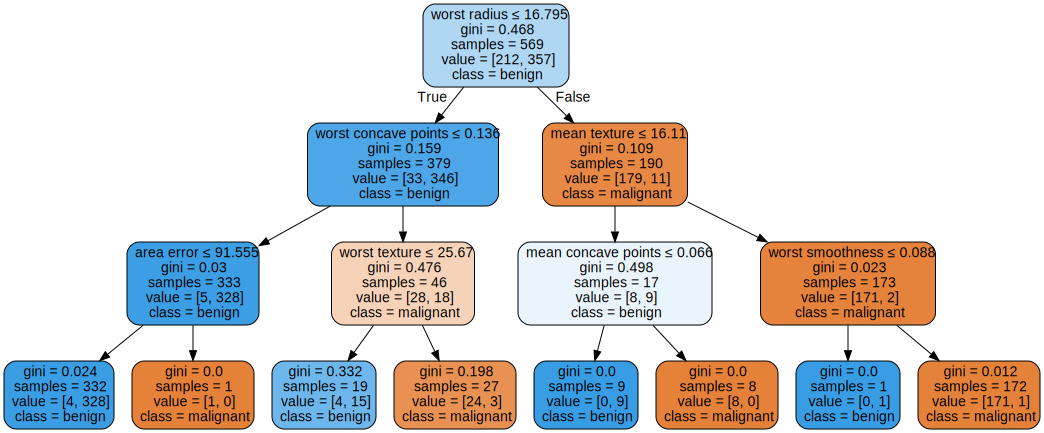

In [ ]:
# 3. Visualize the Tree using Graphviz
dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)
display(graph) # This renders the tree directly in Colab

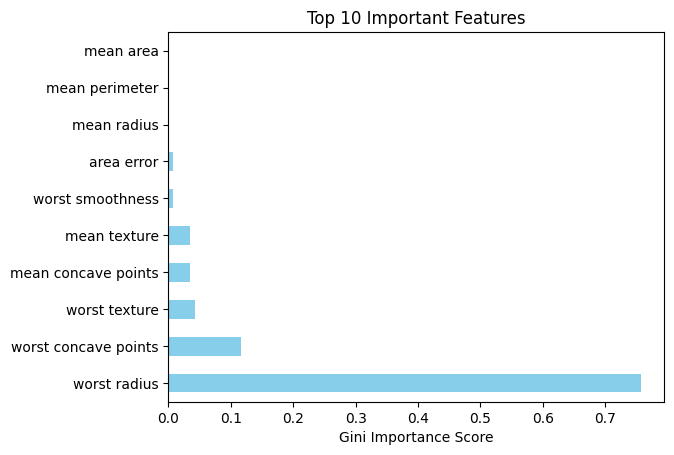

In [ ]:
importance = model.feature_importances_
feat_importance = pd.Series(importance, index=data.feature_names)
feat_importance.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Important Features")
plt.xlabel("Gini Importance Score")
plt.show()